In [1]:
import pandas as pd
from scipy.stats import ks_2samp
import numpy as np

from gsm_benchmarker.results_analyser.prompt_result import MultiPromptResult

from results_notebook_setup import ALPHA, results_loader, original_model_order, OUTPUTS_FOLDER, significant_models_path


100%|██████████| 2/2 [00:01<00:00,  1.69it/s]


In [2]:
full_results = results_loader.full_results

100%|██████████| 2/2 [00:00<00:00,  3.15it/s]


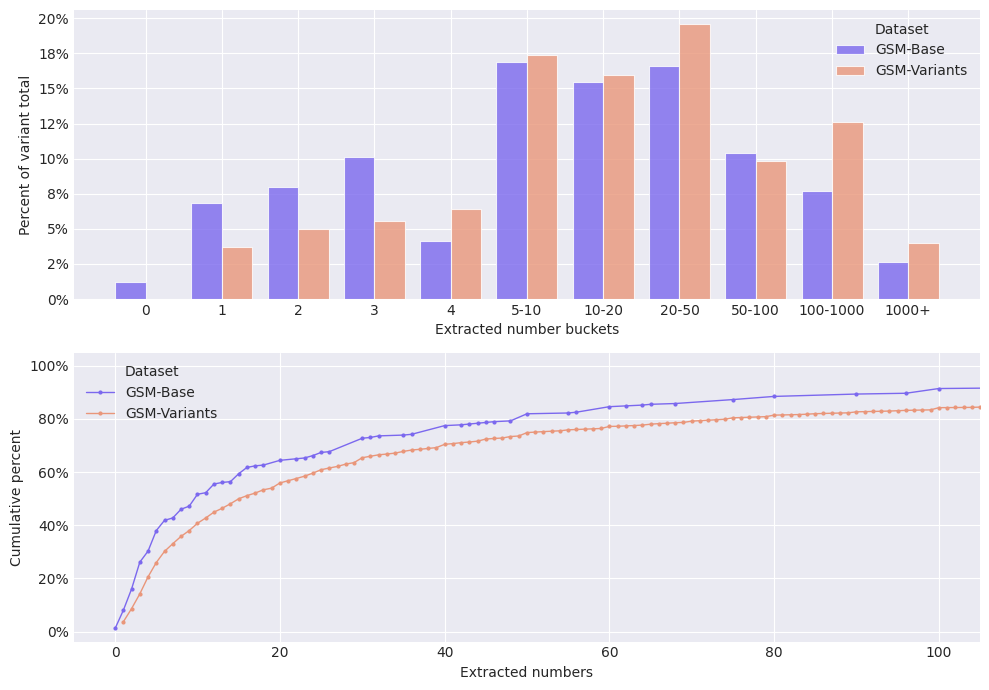

In [3]:
_ = results_loader.gsm.mres.plot_number_counts(save_prefix=OUTPUTS_FOLDER)

### Evaluating number distribution shift in GSM-Variants w.r.t. GSM-Base

In [4]:
number_counts = results_loader.gsm.mres.get_number_counts()[0]
numeric_index = pd.to_numeric(number_counts.index)

gsm8k_samples = np.repeat(numeric_index, number_counts['GSM-Base'].values)
main_samples = np.repeat(numeric_index, number_counts['GSM-Variants'].values)

ks_stat, p_value = ks_2samp(gsm8k_samples, main_samples)

print(f"K-S Statistic: {ks_stat:.4f}")
print(f"P-value: {p_value:.4e}")

K-S Statistic: 0.1201
P-value: 1.2788e-04


## Question 1
Are the accuracy drops reported in the GSM-Symbolic paper actually significant?

Evaluating significance of accuracy change on 'main' variant vs 'GSM8K' variant with GSM-Symbolic prompt.

gemma-2-2b - convergence messages: Model failed to converge with max|grad| = 0.160006 (tol = 0.002, component 1)
  See ?lme4::convergence and ?lme4::troubleshooting.; Model is nearly unidentifiable: very large eigenvalue
 - Rescale variables?


(<Figure size 1000x550 with 1 Axes>, <Figure size 1000x550 with 2 Axes>)

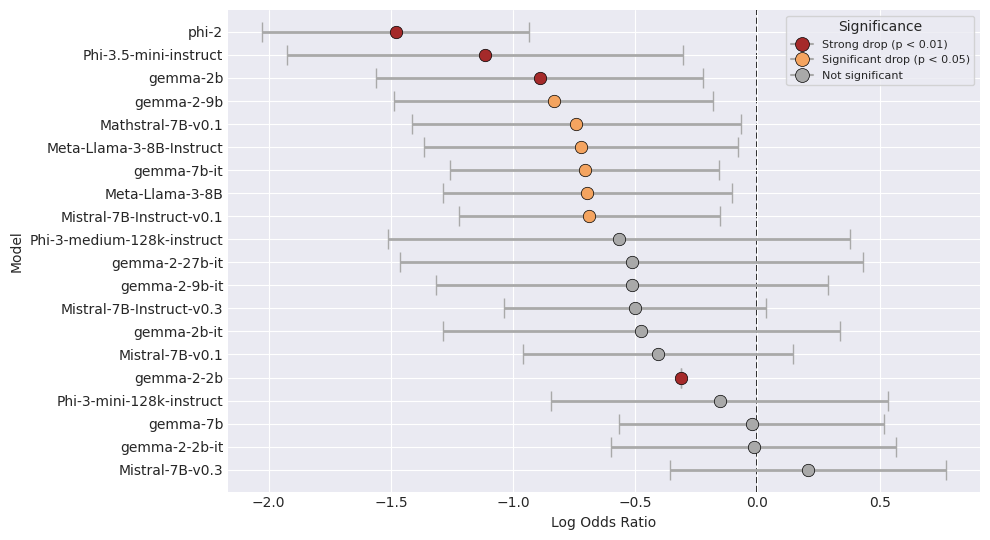

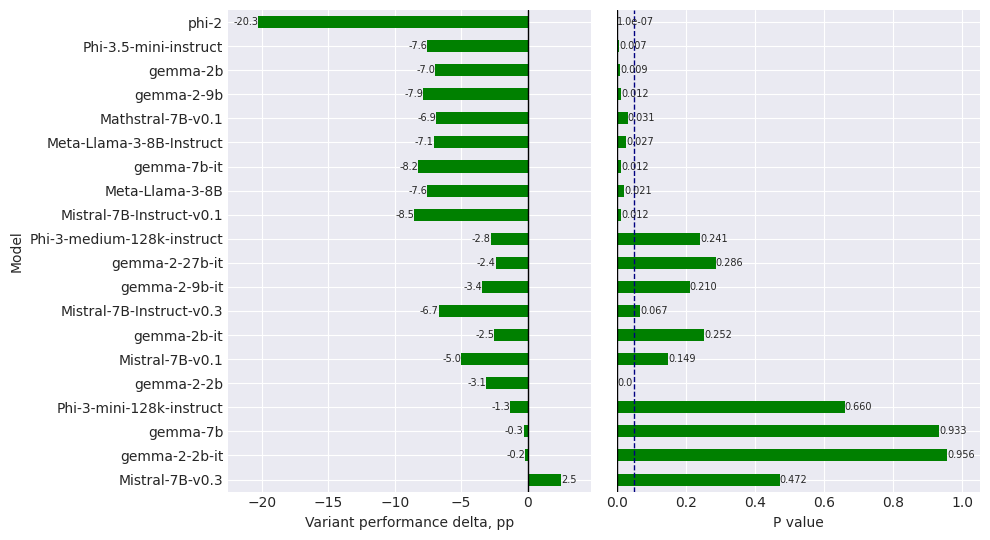

In [5]:
results_loader.gsm.plot_variant_effect()

In [6]:
results_loader.gsm.variant_effect_to_latex(model_order=original_model_order)

\begin{table}[t]
\caption{Results of GSM prompt}
\label{tab:GSM-results}
\begin{tabular}{lccccc}
\toprule
Model & GSM-Base acc & GSM-Variants acc & $\Delta$ Acc & P value & Corrected P value \\
\midrule
gemma-2b & 19.0 & 12.0 & -6.96 & \textbf{0.009} & 0.153 \\
gemma-2b-it & 10.0 & 7.5 & -2.52 & 0.252 & 1.000 \\
gemma-7b & 48.0 & 47.7 & -0.30 & 0.933 & 1.000 \\
gemma-7b-it & 31.0 & 22.8 & -8.22 & \textbf{0.012} & 0.188 \\
gemma-2-2b & 24.0 & 20.9 & -3.12 & \textbf{< 0.001} & \textbf{< 0.001} \\
gemma-2-2b-it & 42.0 & 41.8 & -0.18 & 0.956 & 1.000 \\
gemma-2-9b & 69.0 & 61.1 & -7.88 & \textbf{0.012} & 0.188 \\
gemma-2-9b-it & 86.0 & 82.6 & -3.40 & 0.210 & 1.000 \\
gemma-2-27b-it & 90.0 & 87.6 & -2.40 & 0.286 & 1.000 \\
phi-2 & 60.0 & 39.7 & -20.26 & \textbf{< 0.001} & \textbf{< 0.001} \\
Phi-3-mini-128k-instruct & 80.0 & 78.7 & -1.30 & 0.660 & 1.000 \\
Phi-3-medium-128k-instruct & 91.0 & 88.2 & -2.78 & 0.241 & 1.000 \\
Phi-3.5-mini-instruct & 87.0 & 79.4 & -7.58 & \textbf{0.007} & 0.126 

In [7]:
significant_models = results_loader.gsm.get_significant_models(alpha=ALPHA, drop_only=True)
significant_models

['phi-2',
 'Phi-3.5-mini-instruct',
 'gemma-2b',
 'gemma-2-9b',
 'Mathstral-7B-v0.1',
 'Meta-Llama-3-8B-Instruct',
 'gemma-7b-it',
 'Meta-Llama-3-8B',
 'Mistral-7B-Instruct-v0.1',
 'gemma-2-2b']

In [8]:
len(significant_models)

10

In [9]:
for key, res in full_results.items():
    if key != 'GSM':
        res.models = significant_models

with open(significant_models_path, 'w') as f:
    f.writelines([f"{m}\n" for m in significant_models])


## Question 2
Do alternative prompt formats remove the variant dependency?

(<Figure size 1000x350 with 1 Axes>, <Figure size 1000x350 with 2 Axes>)

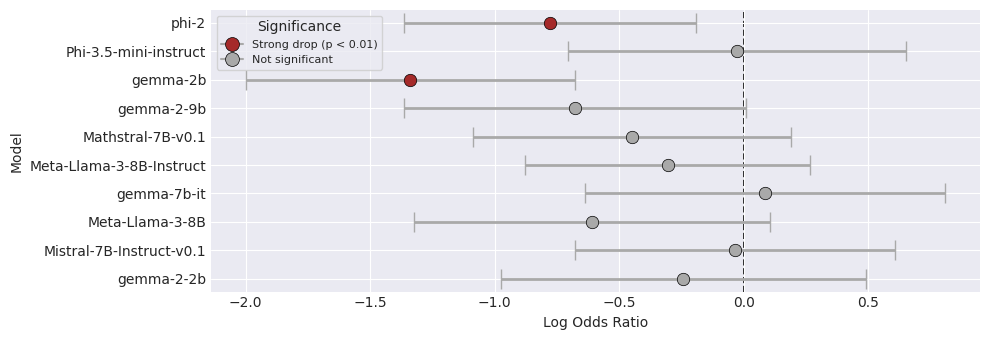

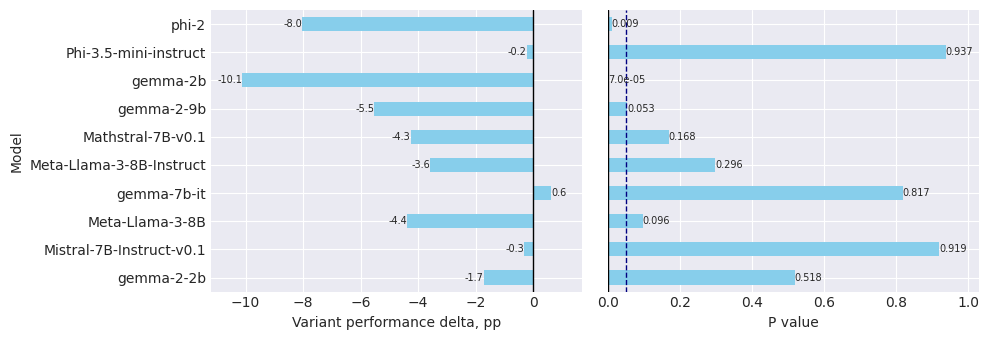

In [10]:
results_loader.nonformal.plot_variant_effect(model_order=significant_models[::-1])

In [11]:
results_loader.nonformal.variant_effect_to_latex(model_order=significant_models)

\begin{table}[t]
\caption{Results of Simple NL prompt}
\label{tab:NL-simple-results}
\begin{tabular}{lccccc}
\toprule
Model & GSM-Base acc & GSM-Variants acc & $\Delta$ Acc & P value & Corrected P value \\
\midrule
phi-2 & 45.0 & 37.0 & -8.04 & \textbf{0.009} & 0.083 \\
Phi-3.5-mini-instruct & 73.0 & 72.8 & -0.22 & 0.937 & 1.000 \\
gemma-2b & 21.0 & 10.9 & -10.12 & \textbf{< 0.001} & \textbf{< 0.001} \\
gemma-2-9b & 67.0 & 61.5 & -5.52 & 0.053 & 0.427 \\
Mathstral-7B-v0.1 & 73.0 & 68.7 & -4.26 & 0.168 & 1.000 \\
Meta-Llama-3-8B-Instruct & 63.0 & 59.4 & -3.58 & 0.296 & 1.000 \\
gemma-7b-it & 24.0 & 24.6 & 0.64 & 0.817 & 1.000 \\
Meta-Llama-3-8B & 21.0 & 16.6 & -4.38 & 0.096 & 0.672 \\
Mistral-7B-Instruct-v0.1 & 26.0 & 25.7 & -0.30 & 0.919 & 1.000 \\
gemma-2-2b & 20.0 & 18.3 & -1.72 & 0.518 & 1.000 \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}[t]
\caption{Additional statistics for results of Simple NL prompt}
\label{tab:NL-simple-stats}
\begin{tabular}{lcccc}
\toprule
Model & O

gemma-2-2b - convergence messages: Model failed to converge with max|grad| = 0.160257 (tol = 0.002, component 1)
  See ?lme4::convergence and ?lme4::troubleshooting.; Model is nearly unidentifiable: very large eigenvalue
 - Rescale variables?


(<Figure size 1000x350 with 1 Axes>, <Figure size 1000x350 with 2 Axes>)

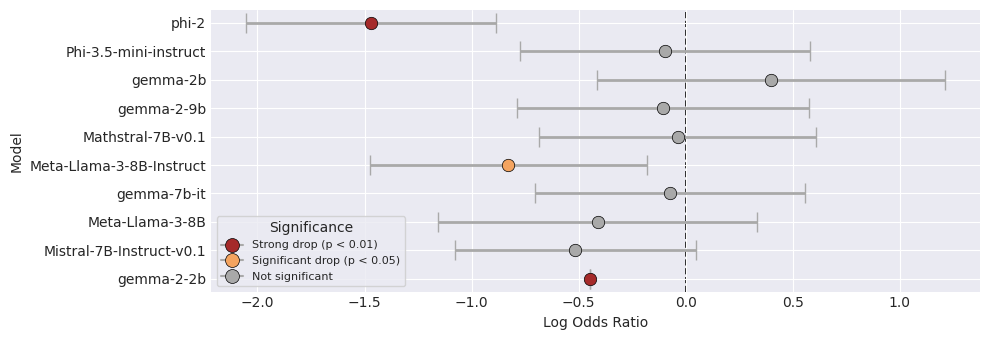

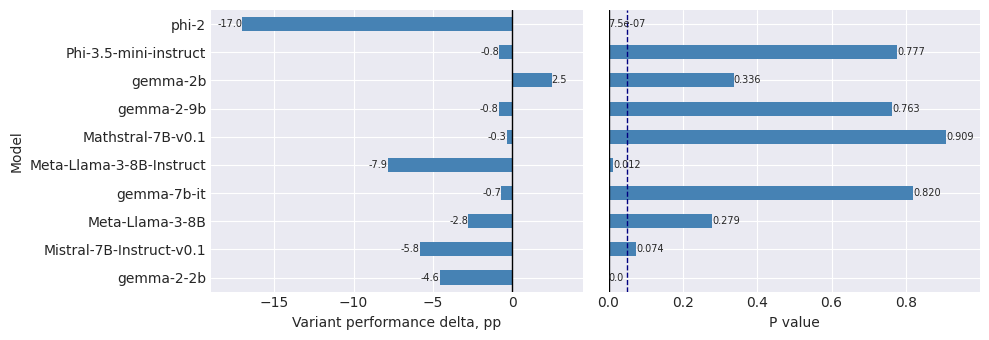

In [12]:
results_loader.formal.plot_variant_effect(model_order=significant_models[::-1])

In [13]:
results_loader.formal.variant_effect_to_latex(model_order=significant_models)

\begin{table}[t]
\caption{Results of Structured NL prompt}
\label{tab:NL-structured-results}
\begin{tabular}{lccccc}
\toprule
Model & GSM-Base acc & GSM-Variants acc & $\Delta$ Acc & P value & Corrected P value \\
\midrule
phi-2 & 63.0 & 46.0 & -17.04 & \textbf{< 0.001} & \textbf{< 0.001} \\
Phi-3.5-mini-instruct & 77.0 & 76.2 & -0.80 & 0.777 & 1.000 \\
gemma-2b & 12.0 & 14.5 & 2.50 & 0.336 & 1.000 \\
gemma-2-9b & 72.0 & 71.2 & -0.84 & 0.763 & 1.000 \\
Mathstral-7B-v0.1 & 78.0 & 77.7 & -0.34 & 0.909 & 1.000 \\
Meta-Llama-3-8B-Instruct & 76.0 & 68.1 & -7.86 & \textbf{0.012} & 0.097 \\
gemma-7b-it & 29.0 & 28.3 & -0.68 & 0.820 & 1.000 \\
Meta-Llama-3-8B & 16.0 & 13.2 & -2.78 & 0.279 & 1.000 \\
Mistral-7B-Instruct-v0.1 & 35.0 & 29.2 & -5.82 & 0.074 & 0.515 \\
gemma-2-2b & 29.0 & 24.4 & -4.58 & \textbf{< 0.001} & \textbf{< 0.001} \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}[t]
\caption{Additional statistics for results of Structured NL prompt}
\label{tab:NL-structured-stats}
\be

(<Figure size 1000x350 with 1 Axes>, <Figure size 1000x350 with 2 Axes>)

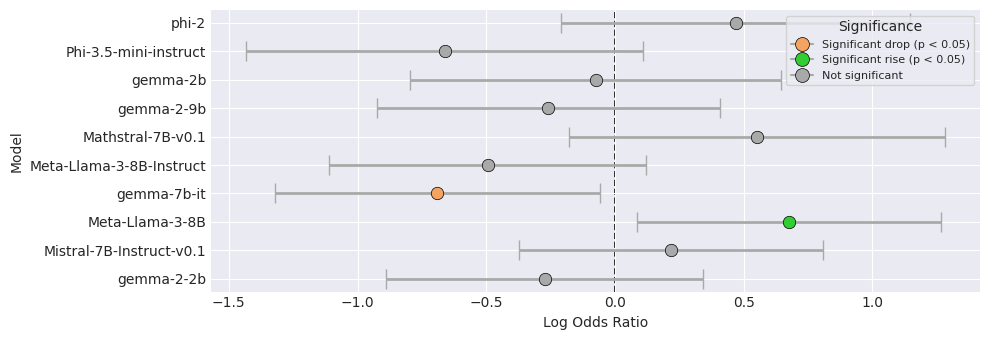

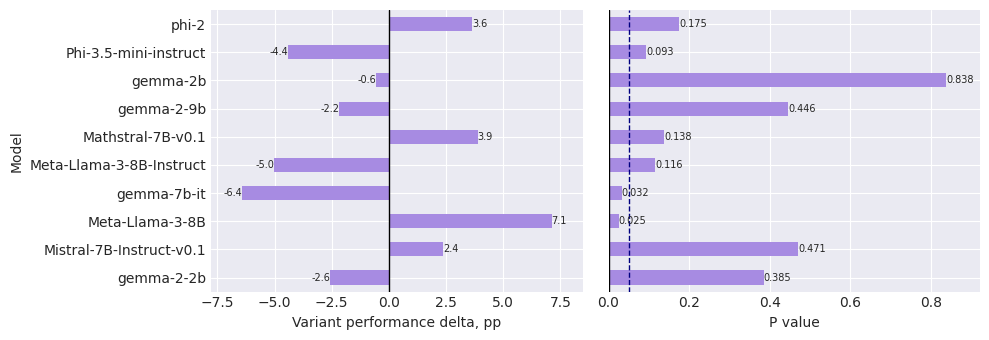

In [14]:
results_loader.short_code.plot_variant_effect(model_order=significant_models[::-1])

In [15]:
results_loader.short_code.variant_effect_to_latex(model_order=significant_models)

\begin{table}[t]
\caption{Results of Simple code-output prompt}
\label{tab:code-simple-results}
\begin{tabular}{lccccc}
\toprule
Model & GSM-Base acc & GSM-Variants acc & $\Delta$ Acc & P value & Corrected P value \\
\midrule
phi-2 & 63.0 & 66.6 & 3.64 & 0.175 & 0.875 \\
Phi-3.5-mini-instruct & 81.0 & 76.6 & -4.42 & 0.093 & 0.745 \\
gemma-2b & 14.0 & 13.4 & -0.56 & 0.838 & 1.000 \\
gemma-2-9b & 68.0 & 65.8 & -2.18 & 0.446 & 1.000 \\
Mathstral-7B-v0.1 & 75.0 & 78.9 & 3.88 & 0.138 & 0.830 \\
Meta-Llama-3-8B-Instruct & 67.0 & 62.0 & -5.02 & 0.116 & 0.811 \\
gemma-7b-it & 47.0 & 40.6 & -6.42 & \textbf{0.032} & 0.291 \\
Meta-Llama-3-8B & 48.0 & 55.1 & 7.12 & \textbf{0.025} & 0.252 \\
Mistral-7B-Instruct-v0.1 & 41.0 & 43.4 & 2.36 & 0.471 & 1.000 \\
gemma-2-2b & 22.0 & 19.4 & -2.58 & 0.385 & 1.000 \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}[t]
\caption{Additional statistics for results of Simple code-output prompt}
\label{tab:code-simple-stats}
\begin{tabular}{lcccc}
\toprule
Mode

gemma-2-2b - convergence messages: Model failed to converge with max|grad| = 0.162445 (tol = 0.002, component 1)
  See ?lme4::convergence and ?lme4::troubleshooting.; Model is nearly unidentifiable: very large eigenvalue
 - Rescale variables?


(<Figure size 1000x350 with 1 Axes>, <Figure size 1000x350 with 2 Axes>)

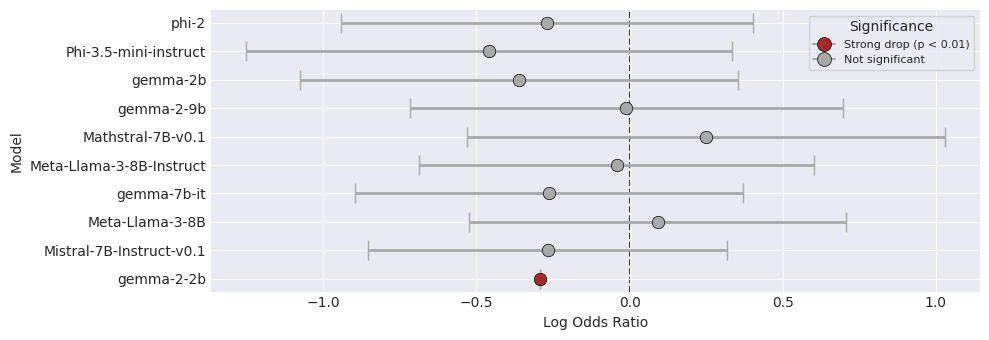

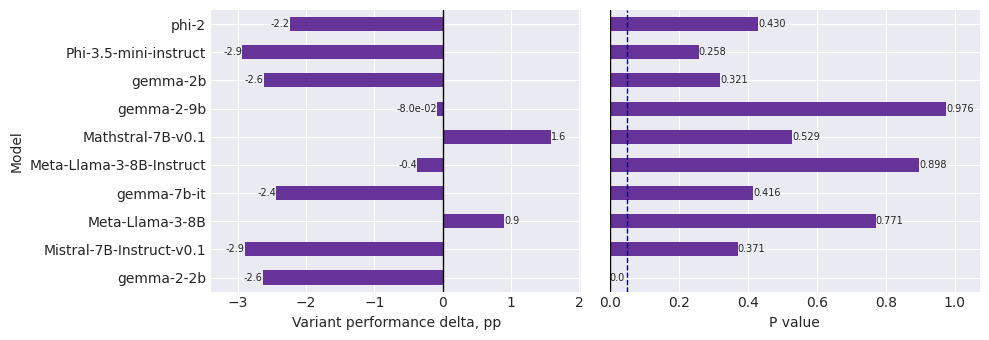

In [16]:
results_loader.long_code.plot_variant_effect(model_order=significant_models[::-1])

In [17]:
results_loader.long_code.variant_effect_to_latex(model_order=significant_models)

\begin{table}[t]
\caption{Results of Structured code-output prompt}
\label{tab:code-structured-results}
\begin{tabular}{lccccc}
\toprule
Model & GSM-Base acc & GSM-Variants acc & $\Delta$ Acc & P value & Corrected P value \\
\midrule
phi-2 & 66.0 & 63.8 & -2.24 & 0.430 & 1.000 \\
Phi-3.5-mini-instruct & 83.0 & 80.1 & -2.94 & 0.258 & 1.000 \\
gemma-2b & 16.0 & 13.4 & -2.62 & 0.321 & 1.000 \\
gemma-2-9b & 68.0 & 67.9 & -0.08 & 0.976 & 1.000 \\
Mathstral-7B-v0.1 & 78.0 & 79.6 & 1.58 & 0.529 & 1.000 \\
Meta-Llama-3-8B-Instruct & 75.0 & 74.6 & -0.38 & 0.898 & 1.000 \\
gemma-7b-it & 43.0 & 40.6 & -2.44 & 0.416 & 1.000 \\
Meta-Llama-3-8B & 49.0 & 49.9 & 0.90 & 0.771 & 1.000 \\
Mistral-7B-Instruct-v0.1 & 47.0 & 44.1 & -2.90 & 0.371 & 1.000 \\
gemma-2-2b & 25.0 & 22.4 & -2.64 & \textbf{< 0.001} & \textbf{< 0.001} \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}[t]
\caption{Additional statistics for results of Structured code-output prompt}
\label{tab:code-structured-stats}
\begin{tabular

In [18]:
# models to be used for plots later - the ones that show significant variant effect on at least one other prompt
demo_models = [
    'gemma-2b',
    'gemma-2-2b',
    'gemma-7b-it',
    'phi-2',
    'Meta-Llama-3-8B',
    'Meta-Llama-3-8B-Instruct',
]


### Summary of all prompts and models


In [19]:
all_prompts_result = MultiPromptResult(full_results, save_prefix=OUTPUTS_FOLDER)
all_prompts_result.summary

gemma-2-2b - convergence messages: Model failed to converge with max|grad| = 0.154273 (tol = 0.002, component 1)
  See ?lme4::convergence and ?lme4::troubleshooting.; Model is nearly unidentifiable: very large eigenvalue
 - Rescale variables?
Mistral-7B-Instruct-v0.1 - convergence messages: Model failed to converge with max|grad| = 0.163852 (tol = 0.002, component 1)
  See ?lme4::convergence and ?lme4::troubleshooting.; Model is nearly unidentifiable: very large eigenvalue
 - Rescale variables?
Phi-3.5-mini-instruct - convergence messages: Model failed to converge with max|grad| = 0.163712 (tol = 0.002, component 1)
  See ?lme4::convergence and ?lme4::troubleshooting.; Model is nearly unidentifiable: very large eigenvalue
 - Rescale variables?
gemma-7b-it - convergence messages: Model failed to converge with max|grad| = 0.159456 (tol = 0.002, component 1)
  See ?lme4::convergence and ?lme4::troubleshooting.; Model is nearly unidentifiable: very large eigenvalue
 - Rescale variables?
ge

model                                     Mathstral-7B-v0.1 Meta-Llama-3-8B  \
prompt          quantity                                                      
GSM             GSM8K_acc                              82.0            55.0   
                main_acc                              75.12           47.44   
                delta_symb_acc_diff                   -6.88           -7.56   
                delta_symb_log_or                 -0.741676       -0.696072   
                delta_symb_or                      0.476315         0.49854   
...                                                     ...             ...   
code-structured number_effect_significant             False           False   
                delta_symb_ne_log_or               0.211092          0.1267   
                delta_symb_ne_or                   1.235026        1.135077   
                delta_symb_ne_p_value              0.618671        0.698976   
                delta_symb_ne_significant             False           False   

model                                     Meta-Llama-3-8B-Instruct  \
prompt          quantity                                             
GSM             GSM8K_acc                                     77.0   
                main_acc                                     69.92   
                delta_symb_acc_diff                          -7.08   
                delta_symb_log_or                        -0.722251   
                delta_symb_or                             0.485658   
...                                                            ...   
code-structured number_effect_significant                    False   
                delta_symb_ne_log_or                     -0.217541   
                delta_symb_ne_or                          0.804495   
                delta_symb_ne_p_value                     0.535686   
                delta_symb_ne_significant                    False   

model                                     Mistral-7B-Instruct-v0.1  \
prompt          quantity                                             
GSM             GSM8K_acc                                     36.0   
                main_acc                                     27.46   
                delta_symb_acc_diff                          -8.54   
                delta_symb_log_or                         -0.68782   
                delta_symb_or                             0.502671   
...                                                            ...   
code-structured number_effect_significant                    False   
                delta_symb_ne_log_or                     -0.310404   
                delta_symb_ne_or                          0.733151   
                delta_symb_ne_p_value                     0.316342   
                delta_symb_ne_significant                    False   

model                                     Mistral-7B-Instruct-v0.3  \
prompt          quantity                                             
GSM             GSM8K_acc                                     52.0   
                main_acc                                     45.32   
                delta_symb_acc_diff                          -6.68   
                delta_symb_log_or                        -0.500421   
                delta_symb_or                             0.606276   
...                                                            ...   
code-structured number_effect_significant                      NaN   
                delta_symb_ne_log_or                           NaN   
                delta_symb_ne_or                               NaN   
                delta_symb_ne_p_value                          NaN   
                delta_symb_ne_significant                      NaN   

model                                     Mistral-7B-v0.1 Mistral-7B-v0.3  \
prompt          quantity                                                    
GSM             GSM8K_acc                            38.0            33.0   
        

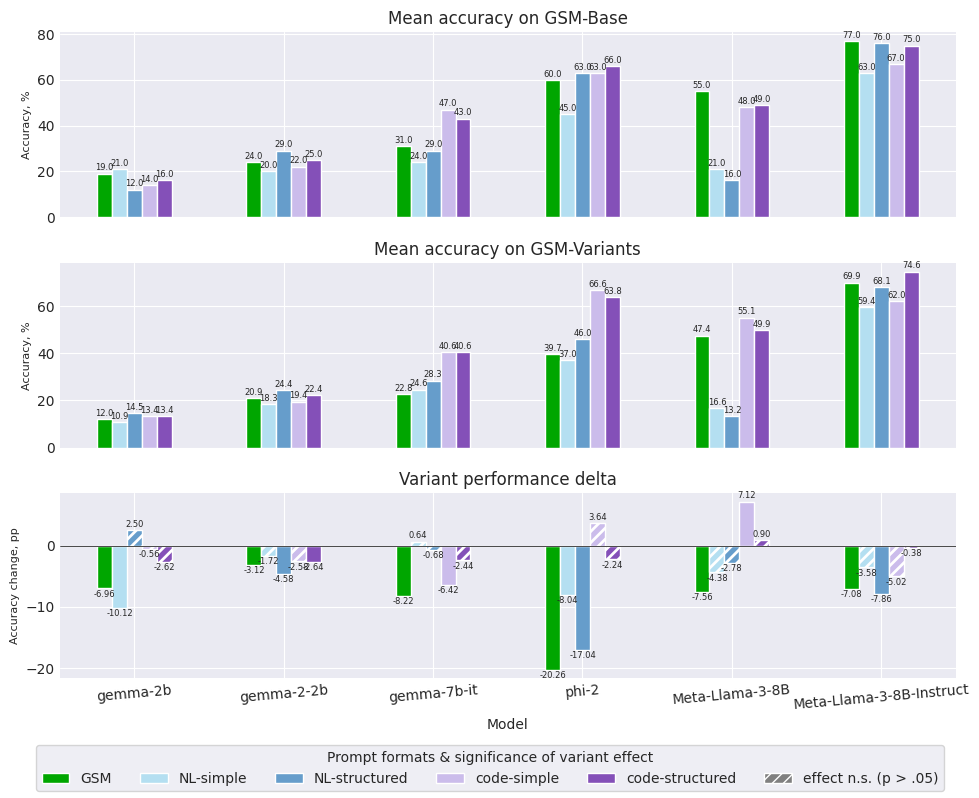

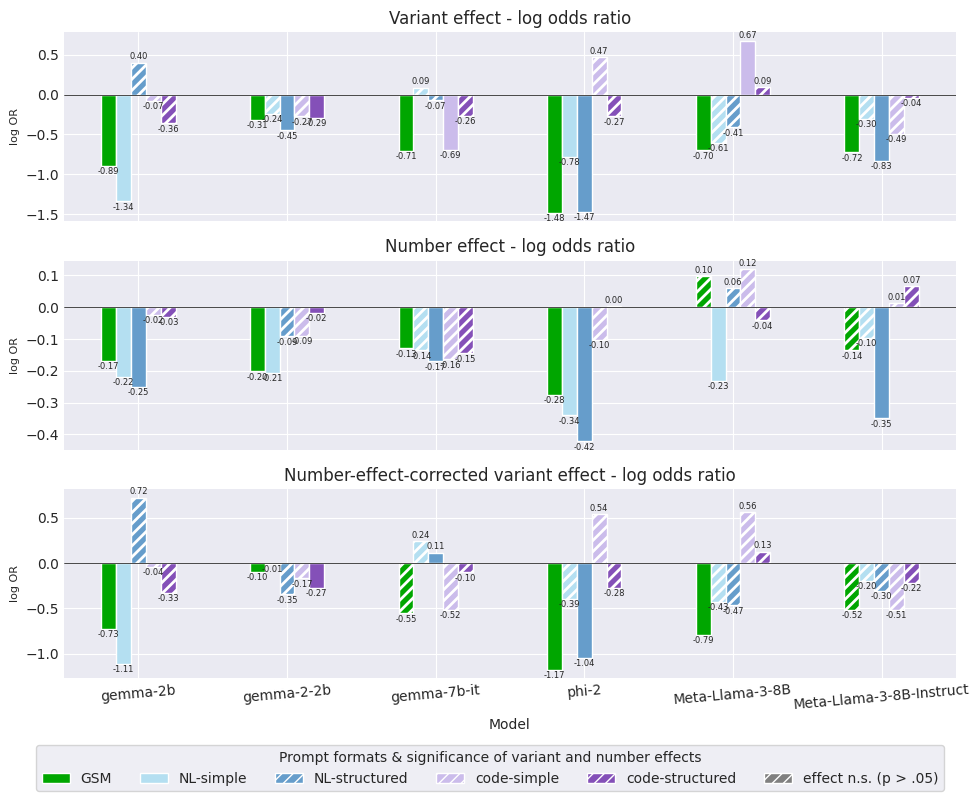

In [20]:
fig = all_prompts_result.plot_prompt_comparison(models=demo_models, add_bar_labels=True, x_labels_rotation=5)

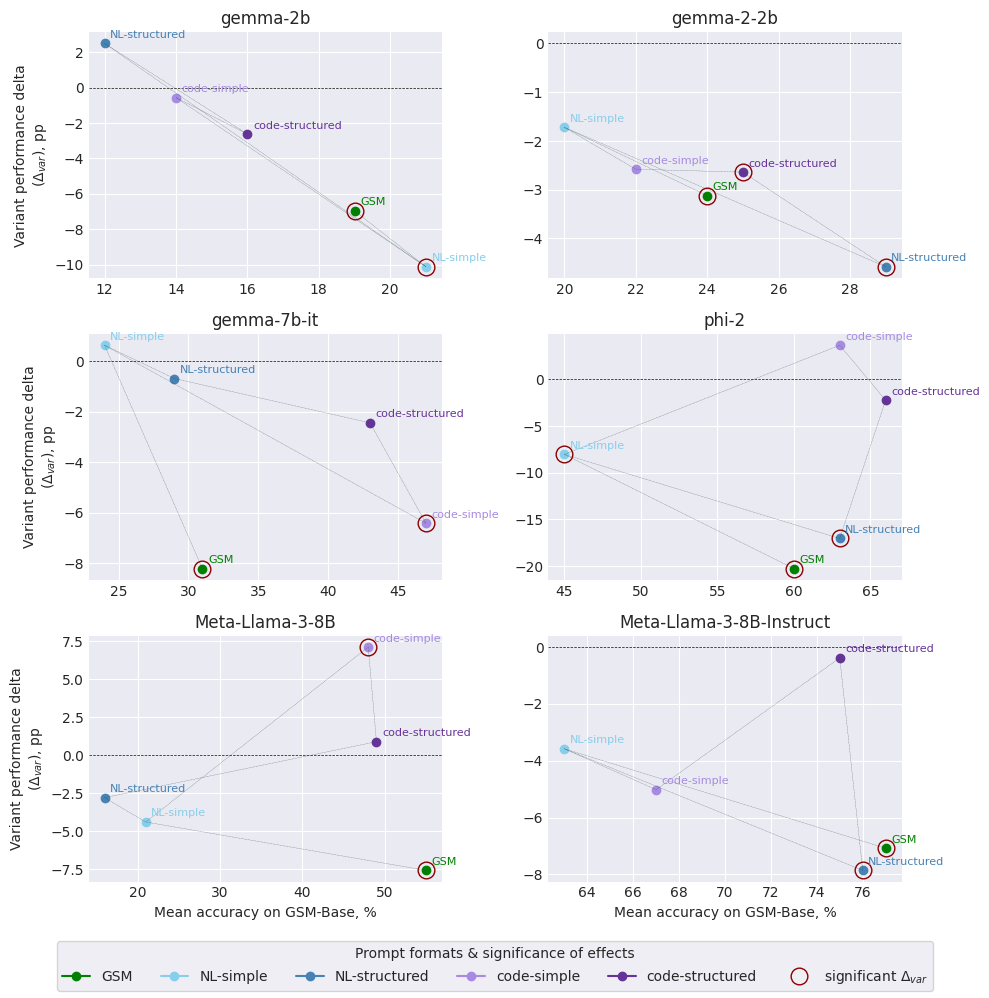

In [21]:
fig = all_prompts_result.plot_prompt_acc_evolution(models=demo_models, n_cols=2, sharex=False, sharey=False, equal_aspect=False, figsize=(10, 10), bottom_margin=.06)


### Diagnostics data for the variant effect fits

In [22]:
def make_fit_diagnostics_summary(name):

    all_diagnostics = []
    for prompt_format, res in full_results.items():  # your dict of {format_name: diagnostics_df}
        df = getattr(res, name)[1].reset_index()
        df['prompt_format'] = prompt_format
        all_diagnostics.append(df)

    combined_diagnostics = pd.concat(all_diagnostics, ignore_index=True)
    total_fits = len(combined_diagnostics)
    clean_fits = combined_diagnostics[
        (~combined_diagnostics['fit_failed']) &
        (~combined_diagnostics['is_singular']) &
        (combined_diagnostics['convergence_messages'] == '')
    ]

    cond = combined_diagnostics['is_singular'] | (combined_diagnostics['convergence_messages'] != '')
    flagged_fits = combined_diagnostics[cond]

    print(f"{len(clean_fits)} / {total_fits} fits converged cleanly")
    print(flagged_fits[['model', 'prompt_format', 'is_singular', 'convergence_messages']])
    print()

    if flagged_fits.size:
        print("Convergence messages:")
        for i in range(flagged_fits.shape[0]):
            print(f"#{flagged_fits.index[i]}", flagged_fits.iloc[i].convergence_messages)
            print()

    print("Clean fits summary")
    print(clean_fits['ranef_variance'].agg(['min', 'max', 'mean']))


In [23]:
make_fit_diagnostics_summary('variant_effect')

57 / 60 fits converged cleanly
         model    prompt_format  is_singular  \
11  gemma-2-2b              GSM        False   
35  gemma-2-2b    Structured NL        False   
55  gemma-2-2b  Structured Code        False   

                                 convergence_messages  
11  Model failed to converge with max|grad| = 0.16...  
35  Model failed to converge with max|grad| = 0.16...  
55  Model failed to converge with max|grad| = 0.16...  

Convergence messages:
#11 Model failed to converge with max|grad| = 0.160006 (tol = 0.002, component 1)
  See ?lme4::convergence and ?lme4::troubleshooting.; Model is nearly unidentifiable: very large eigenvalue
 - Rescale variables?

#35 Model failed to converge with max|grad| = 0.160257 (tol = 0.002, component 1)
  See ?lme4::convergence and ?lme4::troubleshooting.; Model is nearly unidentifiable: very large eigenvalue
 - Rescale variables?

#55 Model failed to converge with max|grad| = 0.162445 (tol = 0.002, component 1)
  See ?lme4::converge

### Number effect tables

In [24]:
# number effect - GLMM results
all_prompts_result.number_effect_to_latex("number_effect", models=significant_models)

\begin{table}
\caption{Odds ratios and significance of the number effect across models and prompt formats. Formatted as: Odds Ratio \\ Raw $p$ / Corrected $p$.}
\label{tab:number_effect_odds}
\begin{tabular}{lccccc}
\toprule
prompt & GSM & NL-simple & NL-structured & code-simple & code-structured \\
model &  &  &  &  &  \\
\midrule
phi-2 & \makecell{0.76 \\ \textbf{$< \delta$} / \textbf{$< \delta$}} & \makecell{0.71 \\ \textbf{$< \delta$} / \textbf{$< \delta$}} & \makecell{0.66 \\ \textbf{$< \delta$} / \textbf{$< \delta$}} & \makecell{0.90 \\ 0.277 / 0.554} & \makecell{1.00 \\ 0.972 / 0.972} \\
Phi-3.5-mini-instruct & \makecell{0.74 \\ \textbf{$< \delta$} / \textbf{$< \delta$}} & \makecell{0.77 \\ \textbf{$< \delta$} / \textbf{0.002}} & \makecell{0.80 \\ \textbf{$< \delta$} / \textbf{$< \delta$}} & \makecell{1.03 \\ 0.714 / 0.714} & \makecell{0.87 \\ 0.171 / 0.343} \\
gemma-2b & \makecell{0.84 \\ \textbf{0.040} / 0.121} & \makecell{0.80 \\ \textbf{0.011} / \textbf{0.046}} & \makecell{0

In [25]:
# number-effect-corrected variant effect - GLMM results
all_prompts_result.number_effect_to_latex("delta_symb_ne", models=significant_models)

\begin{table}
\caption{Odds ratios and significance of the number effect across models and prompt formats. Formatted as: Odds Ratio \\ Raw $p$ / Corrected $p$.}
\label{tab:number_effect_odds}
\begin{tabular}{lccccc}
\toprule
prompt & GSM & NL-simple & NL-structured & code-simple & code-structured \\
model &  &  &  &  &  \\
\midrule
phi-2 & \makecell{0.31 \\ \textbf{$< \delta$} / \textbf{$< \delta$}} & \makecell{0.67 \\ 0.211 / 0.423} & \makecell{0.35 \\ \textbf{$< \delta$} / \textbf{0.003}} & \makecell{1.72 \\ 0.125 / 0.376} & \makecell{0.76 \\ 0.433 / 0.433} \\
Phi-3.5-mini-instruct & \makecell{0.59 \\ 0.220 / 0.660} & \makecell{1.41 \\ 0.346 / 0.693} & \makecell{1.17 \\ \textbf{$< \delta$} / \textbf{$< \delta$}} & \makecell{0.49 \\ 0.085 / 0.340} & \makecell{0.74 \\ 0.480 / 0.693} \\
gemma-2b & \makecell{0.48 \\ \textbf{0.038} / 0.153} & \makecell{0.33 \\ \textbf{0.002} / \textbf{0.008}} & \makecell{2.05 \\ 0.091 / 0.273} & \makecell{0.96 \\ 0.910 / 0.910} & \makecell{0.72 \\ 0.389 /

In [26]:
make_fit_diagnostics_summary('number_effect')


55 / 60 fits converged cleanly
                       model    prompt_format  is_singular  \
11                gemma-2-2b              GSM        False   
23  Mistral-7B-Instruct-v0.1        Simple NL        False   
34     Phi-3.5-mini-instruct    Structured NL        False   
38               gemma-7b-it    Structured NL        False   
55                gemma-2-2b  Structured Code        False   

                                 convergence_messages  
11  Model failed to converge with max|grad| = 0.15...  
23  Model failed to converge with max|grad| = 0.16...  
34  Model failed to converge with max|grad| = 0.16...  
38  Model failed to converge with max|grad| = 0.15...  
55  Model failed to converge with max|grad| = 0.16...  

Convergence messages:
#11 Model failed to converge with max|grad| = 0.154273 (tol = 0.002, component 1)
  See ?lme4::convergence and ?lme4::troubleshooting.; Model is nearly unidentifiable: very large eigenvalue
 - Rescale variables?

#23 Model failed to conv

In [27]:
results_loader.long_code.number_effect[1]

,fit_failed,is_singular,convergence_messages,ranef_variance,ranef_sd
model,,,,,
Mathstral-7B-v0.1,False,False,,19.067956,4.366687
Meta-Llama-3-8B,False,False,,15.797836,3.974649
Meta-Llama-3-8B-Instruct,False,False,,9.618717,3.101406
Mistral-7B-Instruct-v0.1,False,False,,10.787091,3.284371
Phi-3.5-mini-instruct,False,False,,26.256294,5.124090
gemma-2-2b,False,False,Model failed to converge with max|grad| = 0.16...,7.946997,2.819042
gemma-2-9b,False,False,,16.748927,4.092545
gemma-2b,False,False,,6.274512,2.504898
gemma-7b-it,False,False,,16.217206,4.027059
